In [1]:
import pandas as pd

dumb_ferryterminal_loadshifting = pd.read_excel(
    "outputs/dumb_ferryterminal_loadshifting.xlsx"
)
ferryterminal_loadshifting = pd.read_excel("outputs/ferryterminal_loadshifting.xlsx")

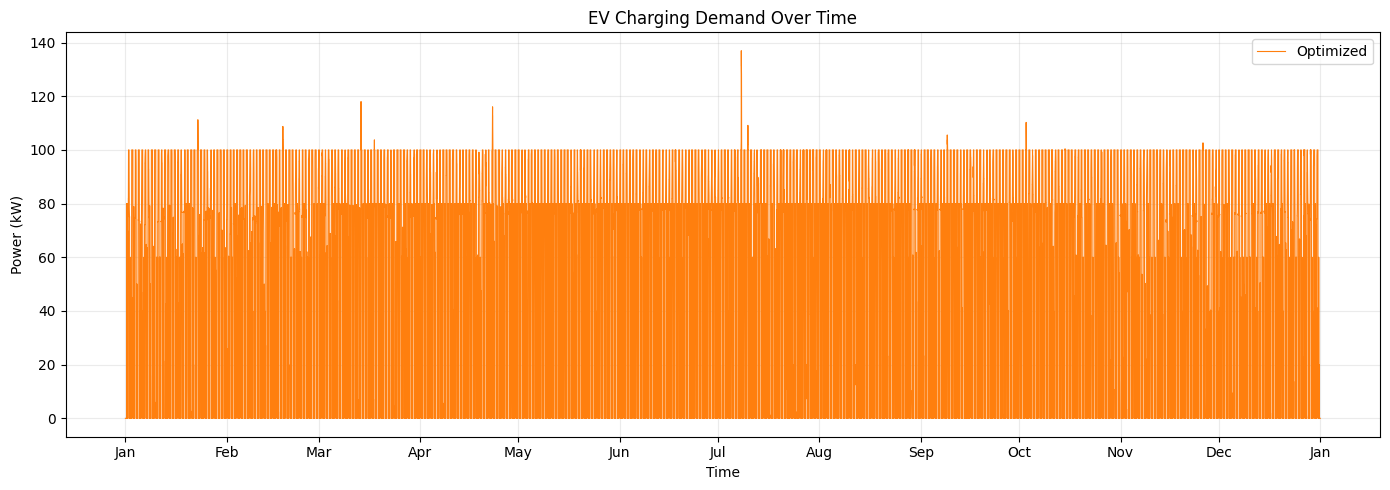

In [2]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

time = pd.to_datetime(ferryterminal_loadshifting["datetime"])
ev_non_optimized = dumb_ferryterminal_loadshifting["EV_charging_kw"]
ev_optimized = ferryterminal_loadshifting["EV_charging_kw"]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    time,
    ev_optimized,
    color="#ff7f0e",
    linewidth=0.8,
    label="Optimized",
)

ax.set_title("EV Charging Demand Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.grid(alpha=0.25)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

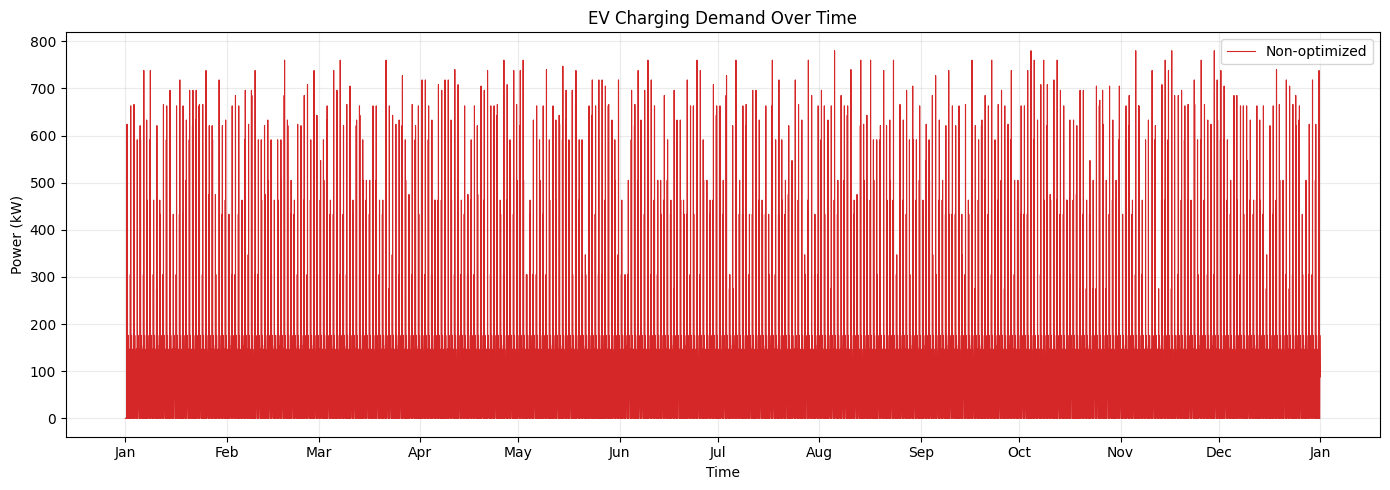

In [3]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

time = pd.to_datetime(ferryterminal_loadshifting["datetime"])
ev_non_optimized = dumb_ferryterminal_loadshifting["EV_charging_kw"]
ev_optimized = ferryterminal_loadshifting["EV_charging_kw"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    time,
    ev_non_optimized,
    color="#d62728",
    linewidth=0.8,
    label="Non-optimized",
)

ax.set_title("EV Charging Demand Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.grid(alpha=0.25)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

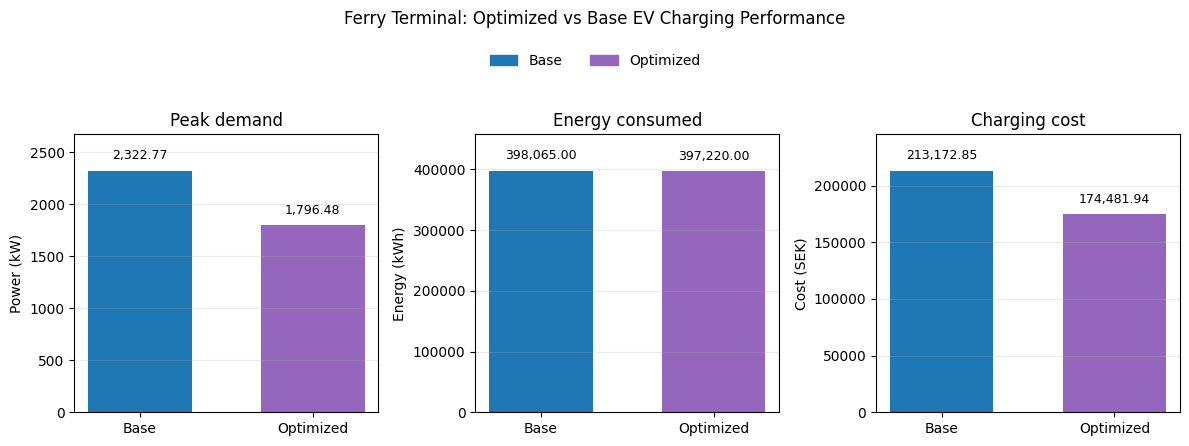

In [4]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Peak demand", "Energy consumed", "Charging cost"]
optimized = [1796.48, 397220, 174481.94]
base = [2322.77, 398065, 213172.85]
y_labels = ["Power (kW)", "Energy (kWh)", "Cost (SEK)"]
scenario_labels = ["Base", "Optimized"]
colors = ["#1f77b4", "#9467bd"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharex=False)

for ax, metric, opt, base_value, y_label in zip(
    axes, metrics, optimized, base, y_labels
):
    values = [base_value, opt]
    bars = ax.bar(scenario_labels, values, color=colors, width=0.6)
    ax.set_title(metric)
    ax.set_ylabel(y_label)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, max(values) * 1.15)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:,.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            clip_on=False,
        )

fig.suptitle("Ferry Terminal: Optimized vs Base EV Charging Performance", y=0.98)
fig.legend(
    [plt.Rectangle((0, 0), 1, 1, color=color) for color in colors],
    scenario_labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.91),
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()

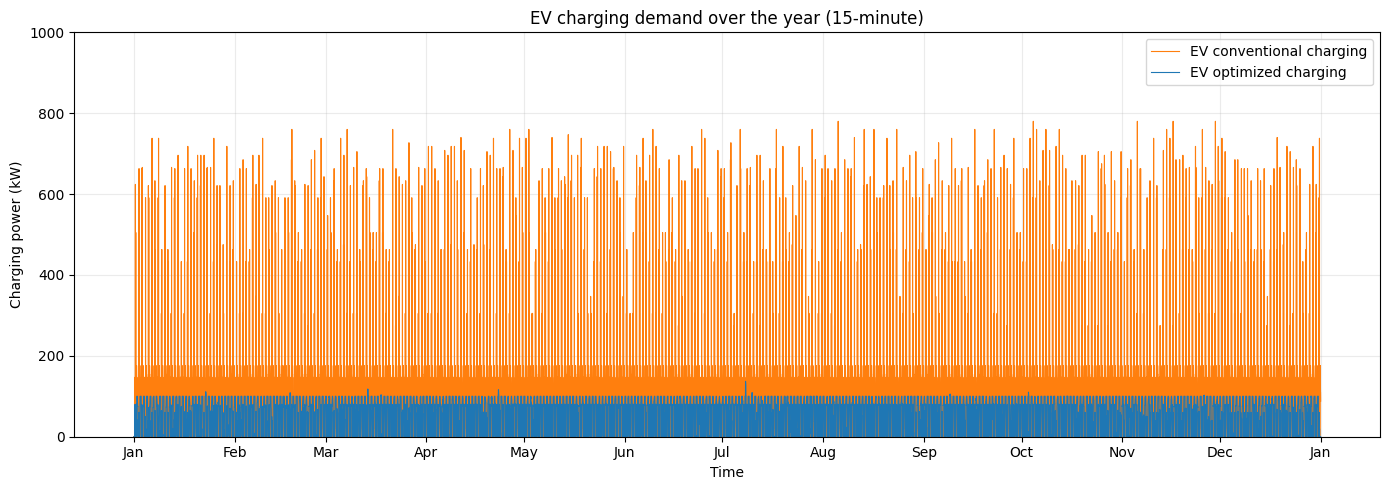

In [5]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

time = pd.to_datetime(ferryterminal_loadshifting["datetime"])
ev_dumb = dumb_ferryterminal_loadshifting["EV_charging_kw"]
ev_optimized = ferryterminal_loadshifting["EV_charging_kw"]

fig, ax = plt.subplots(figsize=(14, 5))

# Dumb charging (orange)
ax.plot(
    time,
    ev_dumb,
    color="#ff7f0e",
    linewidth=0.8,
    label="EV conventional charging",
)

# Optimized charging
ax.plot(
    time,
    ev_optimized,
    color="#1f77b4",
    linewidth=0.8,
    label="EV optimized charging",
)

ax.set_title("EV charging demand over the year (15-minute)")
ax.set_xlabel("Time")
ax.set_ylabel("Charging power (kW)")
ax.grid(alpha=0.25)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(0, 1000)

plt.tight_layout()
plt.show()

In [6]:
# Line loading comparison across scenarios (max loading % and max consecutive hours > 100%)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NETWORK_DIR = Path(
    "../network_data/network_FerryTerminal"
)
SCENARIOS = {
    "Base": "dumb",
    "EV optimized": "optimized",
    "PV + BESS cost min": "pv_bess",
    "PV + BESS peak min.": "pv_bess_peakshave",
}
# Lines 0–15, excluding 6, 7, 8, 14
LINE_IDS = [i for i in range(16) if i not in (6, 7, 8, 14)]
TIMESTEP_HOURS = 0.25  # 15-minute resolution
LOADING_THRESHOLD = 100.0


def max_consecutive_true(mask: np.ndarray) -> int:
    """Longest run of True values (0 if none)."""
    m = mask.astype(np.int8)
    if m.sum() == 0:
        return 0
    padded = np.concatenate([[0], m, [0]])
    d = np.diff(padded)
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0]
    return int((ends - starts).max())


scenario_labels = list(SCENARIOS.keys())
rows = []

for scenario_label, folder in SCENARIOS.items():
    path = (
        NETWORK_DIR
        / folder
        / "outputs"
        / "simulation_results"
        / "res_line"
        / "loading_percent.xlsx"
    )
    loading = pd.read_excel(path, index_col=0)
    for line_id in LINE_IDS:
        s = loading[line_id].to_numpy(dtype=float)
        s = s[~np.isnan(s)]
        rows.append(
            {
                "scenario": scenario_label,
                "line": str(line_id),
                "max_loading_pct": float(np.max(s)),
                "max_consecutive_hours_gt_100": max_consecutive_true(s > LOADING_THRESHOLD)
                * TIMESTEP_HOURS,
            }
        )

line_loading_summary = pd.DataFrame(rows)
line_loading_summary_pivot = {
    "max_loading_pct": line_loading_summary.pivot(
        index="line", columns="scenario", values="max_loading_pct"
    ).reindex(index=[str(i) for i in LINE_IDS], columns=scenario_labels),
    "max_consecutive_hours_gt_100": line_loading_summary.pivot(
        index="line",
        columns="scenario",
        values="max_consecutive_hours_gt_100",
    ).reindex(index=[str(i) for i in LINE_IDS], columns=scenario_labels),
}
line_loading_summary_pivot["max_loading_pct"]


scenario,Base,EV optimized,PV + BESS cost min,PV + BESS peak min.
line,,,,
0,130.880035,118.596287,118.562653,109.621973
1,130.536828,118.267538,118.233841,109.293029
2,129.339372,116.592437,116.558521,107.715935
3,128.139575,114.913992,114.879852,106.458989
4,123.510831,109.739364,109.705236,101.529411
5,122.737762,108.966964,108.932763,100.734128
9,114.197972,100.569479,100.534951,92.078029
10,111.096145,98.319452,98.284854,89.617293
11,111.096161,98.319467,98.284869,89.617308


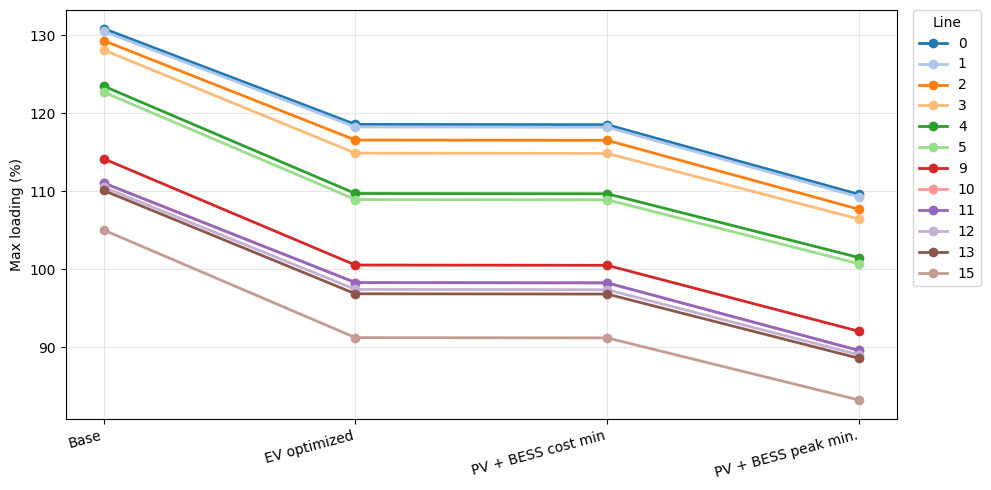

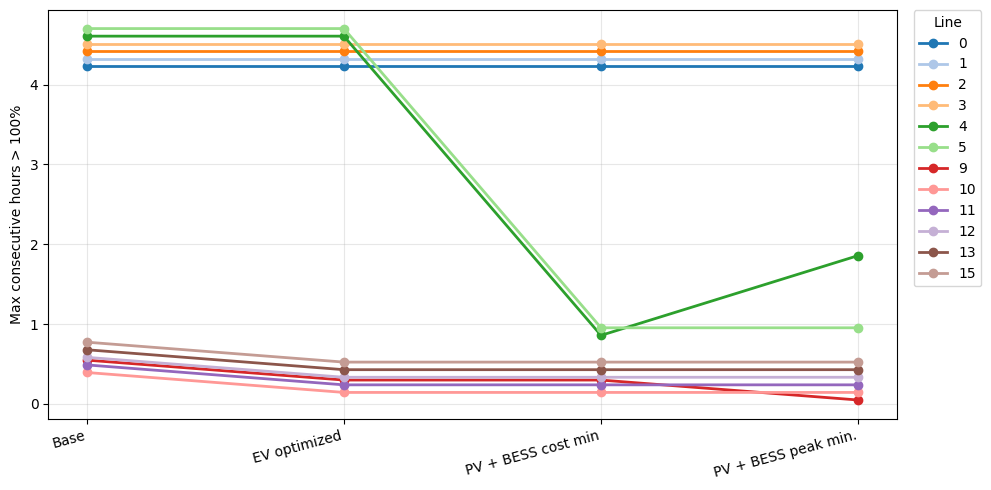

In [8]:
x = np.arange(len(scenario_labels))
lines = [str(i) for i in LINE_IDS]
cmap = plt.get_cmap("tab20")
colors = [cmap(i % cmap.N) for i in range(len(lines))]


def plot_metric(metric_key, ylabel, title, offset=False):
    df = line_loading_summary_pivot[metric_key]
    fig, ax = plt.subplots(figsize=(10, 5))
    y_all = df.to_numpy(dtype=float)
    y_min, y_max = float(np.nanmin(y_all)), float(np.nanmax(y_all))
    yr = y_max - y_min
    if not np.isfinite(yr) or yr == 0:
        yr = 1.0
    eps = 0.02 * yr if offset else 0.0
    n_lines = len(lines)

    for i, line in enumerate(lines):
        y = df.loc[line, scenario_labels].to_numpy(dtype=float)
        y_plot = y + eps * (i - (n_lines - 1) / 2)
        ax.plot(
            x,
            y_plot,
            marker="o",
            linewidth=2,
            label=line,
            color=colors[i],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(scenario_labels, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(
        title="Line",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
    )
    fig.tight_layout()
    return fig


fig_max_loading = plot_metric(
    "max_loading_pct",
    ylabel="Max loading (%)",
    title="",
    offset=False,
)
fig_max_hours = plot_metric(
    "max_consecutive_hours_gt_100",
    ylabel="Max consecutive hours > 100%",
    title="",
    offset=True,
)

plt.show()
